In [2]:
!pip install pandas numpy matplotlib seaborn scikit-learn geopandas folium

Defaulting to user installation because normal site-packages is not writeable


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import folium

In [4]:
# Load the crime data CSV and GeoJSON file
crime_data = pd.read_csv(r'C:\Users\upadh\Desktop\Project Files\WS\crimedata.csv')
india_geo = gpd.read_file(r'C:\Users\upadh\Downloads\states_india.geojson\states_india.geojson')

In [5]:
# Clean and rename columns for consistency
crime_data.columns = crime_data.columns.str.strip().str.replace(' ', '_')  # Replace spaces with underscores
crime_data.rename(columns={'STATE/UT': 'state', 'CRIME_HEAD': 'crime_type'}, inplace=True)

In [6]:
# Filter data for crimes against women (RAPE cases)
women_crimes = crime_data[crime_data['crime_type'] == 'RAPE']

In [7]:
# Reshape the data into a long format where each row represents (state, year, number_of_crimes)
women_crimes_long = women_crimes.melt(id_vars=['state', 'crime_type'], 
                                      var_name='year', value_name='number_of_crimes')

# Convert year to numeric and filter recent years if required
women_crimes_long['year'] = pd.to_numeric(women_crimes_long['year'])

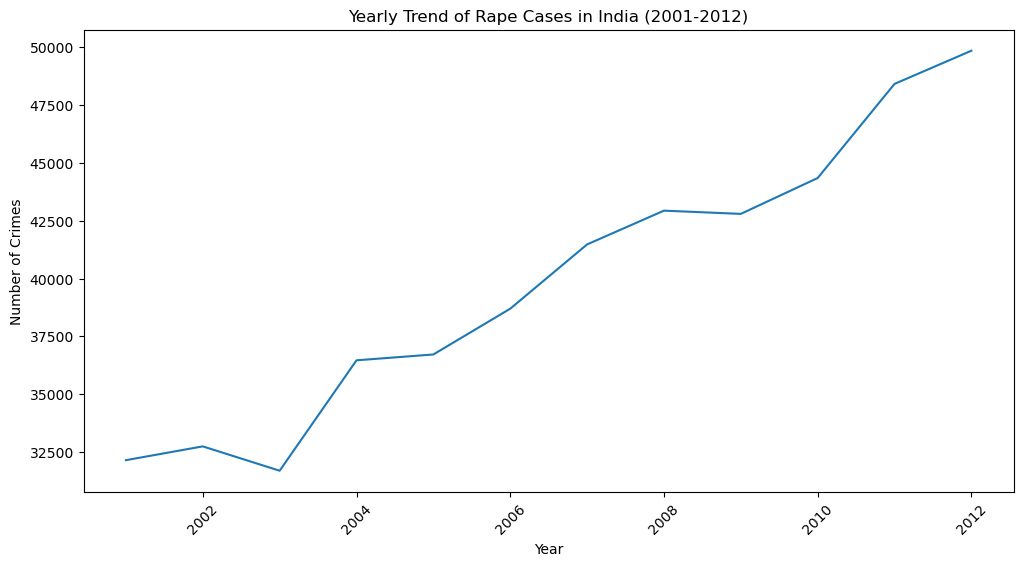

In [8]:
# Plot trend of rape cases over time
plt.figure(figsize=(12, 6))
women_crimes_long.groupby('year')['number_of_crimes'].sum().plot()
plt.title('Yearly Trend of Rape Cases in India (2001-2012)')
plt.xlabel('Year')
plt.ylabel('Number of Crimes')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Check the current CRS of the GeoDataFrame
print(india_geo.crs)

# Reproject to a suitable projected CRS (like EPSG:3857, which is the Web Mercator projection)
india_geo_projected = india_geo.to_crs(epsg=3857)

# Group by state to get total number of crimes
state_crime_totals = women_crimes_long.groupby('state')['number_of_crimes'].sum().reset_index()

# Merge the crime data with the projected GeoJSON for mapping
india_geo_projected.rename(columns={'st_nm': 'state'}, inplace=True)
merged = india_geo_projected.set_index('state').join(state_crime_totals.set_index('state'))

# Calculate centroids for mapping (in projected CRS)
merged['centroid'] = merged.geometry.centroid

# Convert centroids back to the geographic CRS (EPSG:4326) for display on the map
merged = merged.to_crs(epsg=4326)

# Check the merged DataFrame to ensure it has correct data
print(merged.head())


EPSG:4326
                     cartodb_id  state_code  \
state                                         
Telengana                     1           0   
Andaman and Nicobar           2          35   
Andhra Pradesh                3          28   
Arunachal Pradesh             4          12   
Assam                         5          18   

                                                              geometry  \
state                                                                    
Telengana            MULTIPOLYGON (((78.34088 19.88361, 78.35133 19...   
Andaman and Nicobar  MULTIPOLYGON (((93.71976 7.20707, 93.71909 7.2...   
Andhra Pradesh       MULTIPOLYGON (((81.39375 16.3338, 81.39224 16....   
Arunachal Pradesh    MULTIPOLYGON (((96.16261 29.38078, 96.1686 29....   
Assam                MULTIPOLYGON (((89.74323 26.30362, 89.7429 26....   

                     number_of_crimes                          centroid  
state                                                              

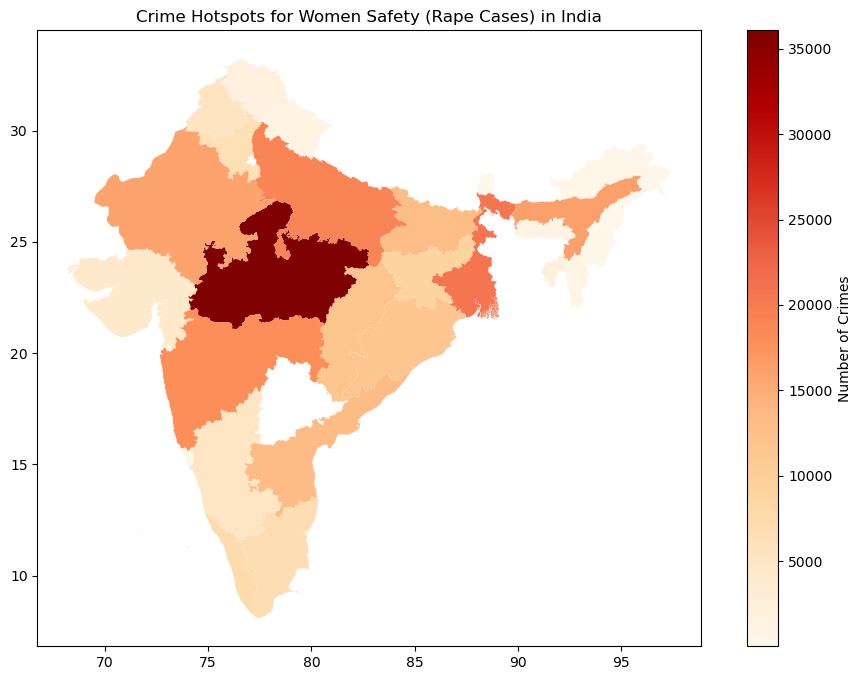

In [12]:
# Plot the crime hotspots on the map
fig, ax = plt.subplots(1, 1, figsize=(12, 8))
merged.plot(column='number_of_crimes', ax=ax, legend=True, cmap='OrRd', legend_kwds={'label': "Number of Crimes"})
plt.title('Crime Hotspots for Women Safety (Rape Cases) in India')
plt.show()

In [13]:
# Step 1: Check the CRS and reproject if necessary
print(india_geo.crs)  # Check the original CRS of the GeoJSON

# Reproject to EPSG:4326 if necessary (for mapping with Folium)
if india_geo.crs != 'EPSG:4326':
    india_geo = india_geo.to_crs(epsg=4326)

# Step 2: Rename columns to ensure a successful merge (assuming 'st_nm' is the state column in GeoJSON)
india_geo.rename(columns={'st_nm': 'state'}, inplace=True)

# Step 3: Group crime data by state to get total number of crimes
state_crime_totals = women_crimes_long.groupby('state')['number_of_crimes'].sum().reset_index()

# Step 4: Merge the crime data with the GeoJSON data
merged = india_geo.set_index('state').join(state_crime_totals.set_index('state'))

# Ensure that there are no missing geometries in the merged data
print(merged[['number_of_crimes', 'geometry']].dropna().head())

# Step 5: Calculate centroids (ensure CRS is EPSG:4326 for latitude/longitude)
merged['centroid'] = merged.geometry.centroid

# Step 6: Create an interactive map with Folium
m = folium.Map(location=[20.5937, 78.9629], zoom_start=5)

# Step 7: Add CircleMarkers for each state based on crime data
for i, row in merged.iterrows():
    if pd.notnull(row['number_of_crimes']) and pd.notnull(row['centroid']):
        # Add CircleMarker for each state
        folium.CircleMarker(
            location=[row['centroid'].y, row['centroid'].x],  # Latitude, Longitude from centroid
            radius=row['number_of_crimes'] / 500,  # Scale marker size by crime number
            color='red',
            fill=True,
            fill_color='red',
            fill_opacity=0.6,
            popup=f"{row.name}: {row['number_of_crimes']} incidents"  # Display state and crime count
        ).add_to(m)

# Step 8: Save the map to an HTML file
m.save('crime_hotspot_map.html')

# Optionally display the map in the notebook
m


EPSG:4326
                   number_of_crimes  \
state                                 
Andhra Pradesh              13479.0   
Arunachal Pradesh             500.0   
Assam                       16178.0   
Bihar                       13124.0   
Chhattisgarh                11838.0   

                                                            geometry  
state                                                                 
Andhra Pradesh     MULTIPOLYGON (((81.39375 16.3338, 81.39224 16....  
Arunachal Pradesh  MULTIPOLYGON (((96.16261 29.38078, 96.1686 29....  
Assam              MULTIPOLYGON (((89.74323 26.30362, 89.7429 26....  
Bihar              MULTIPOLYGON (((84.5072 24.26323, 84.50355 24....  
Chhattisgarh       MULTIPOLYGON (((83.33532 24.09885, 83.35346 24...  


C:\Users\upadh\AppData\Local\Temp\ipykernel_20516\4277476518.py:21: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  merged['centroid'] = merged.geometry.centroid
